<a href="https://colab.research.google.com/github/leman-cap13/DL_projects/blob/main/Computer_Vision_Using_Convolutional_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Implementing Convolutional Layers with PyTorch

In [ ]:
import numpy as np
import torch
from sklearn.datasets import load_sample_images
sample_images =np.stack(load_sample_images()["images"])
sample_images =torch.tensor(sample_images, dtype=torch.float32) / 255

In [ ]:
sample_images.shape  # shape => batch, Height, Width, Channels   batch =N   N, H,W C

torch.Size([2, 427, 640, 3])

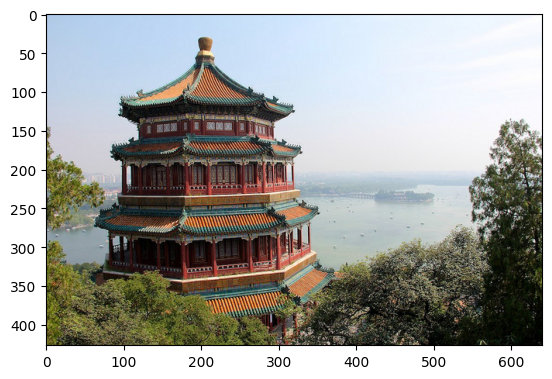

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(sample_images[0])
plt.show()

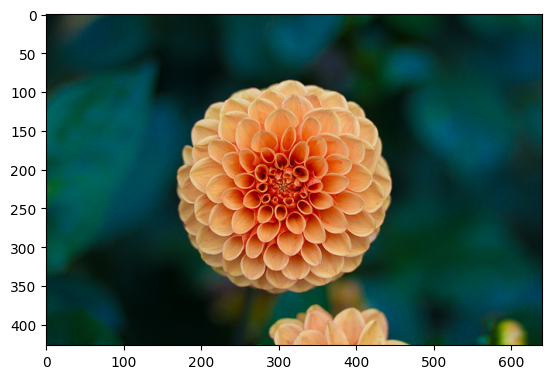

In [ ]:
plt.imshow(sample_images[1])
plt.show()

In [ ]:
#          Batch(N), C, H, W => torch

#matplotlib   B, H, W, C

In [ ]:
#permute


In [ ]:
sample_images_permuted=sample_images.permute(0,3,1,2)
sample_images_permuted.shape

torch.Size([2, 3, 427, 640])

In [ ]:
import torchvision
import torchvision.transforms.v2 as T
cropped_images=T.CenterCrop((70,120))(sample_images_permuted)
cropped_images.shape

torch.Size([2, 3, 70, 120])

In [ ]:
#B, C, H, W   => torch expected shape

In [ ]:
#B, H, W, C

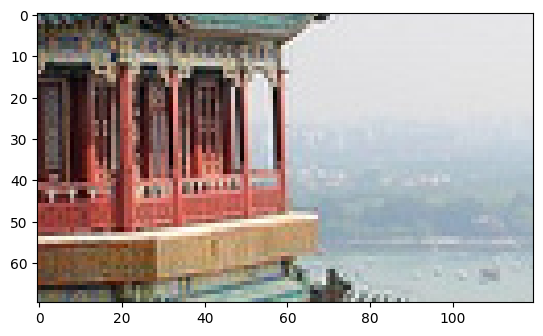

In [ ]:
plt.imshow(cropped_images[0].permute(1,2,0))

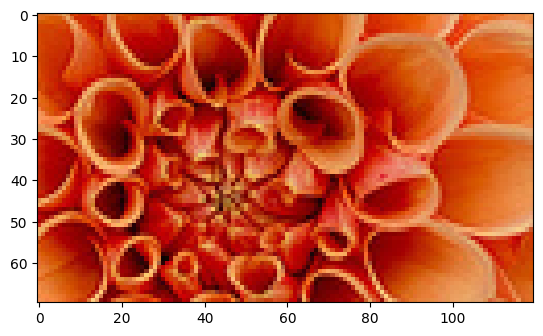

In [ ]:
plt.imshow(cropped_images[1].permute(1,2,0))

In [ ]:
cropped_images.shape

torch.Size([2, 3, 70, 120])

In [ ]:
# I+2P-K / S + 1  => 70 +2*0 -7  /  1  + 1=64

In [ ]:
import torch.nn as nn
torch.manual_seed(42)
conv_layer=nn.Conv2d(
    in_channels=3,    # rgb
    out_channels=32,  # feature map count
    kernel_size=7,    # filter size 7x7
    padding='valid',  # zero padding
    stride=1           # step

)

fmaps=conv_layer(cropped_images)
fmaps.shape


torch.Size([2, 32, 64, 114])

In [ ]:
torch.manual_seed(42)
conv_layer=nn.Conv2d(
    in_channels=3,    # rgb
    out_channels=32,  # feature map count
    kernel_size=7,    # filter size 7x7
    padding=3,       # zero padding
    stride=1           # step

)

fmaps=conv_layer(cropped_images)
fmaps.shape

torch.Size([2, 32, 70, 120])

In [ ]:
conv_layer=nn.Conv2d(
    in_channels=3,    # rgb
    out_channels=32,  # feature map count
    kernel_size=7,    # filter size 7x7
    padding=3,       # zero padding
    stride=1           # step

)

#Implementing Pooling Layers with PyTorch

In [ ]:
import torch.nn as nn


In [ ]:
max_pool=nn.MaxPool2d(kernel_size=3)  # H and W
max_pool

MaxPool2d(kernel_size=3, stride=3, padding=0, dilation=1, ceil_mode=False)

In [ ]:
avg_pool=nn.AvgPool2d(kernel_size=3)
avg_pool

AvgPool2d(kernel_size=3, stride=3, padding=0)

In [ ]:
max_pool = nn.MaxPool2d(kernel_size=2)

In [ ]:
max_pool

MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)

In [ ]:
avg_pool=nn.AvgPool2d(kernel_size=2)

In [ ]:
avg_pool

AvgPool2d(kernel_size=2, stride=2, padding=0)

In [ ]:
import torch.nn.functional as F  # B, C, H, W   128, 64, 12 12
class DepthPool(torch.nn.Module):
    def __init__(self, kernel_size, stride=None, padding=0):
        super().__init__()
        self.kernel_size=kernel_size
        self.stride=stride if stride is not None else kernel_size
        self.padding=padding

    def forward(self, inputs):
        batch, channels, height, width=inputs.shape
        Z=inputs.view(batch, channels, height * width)
        Z=Z.permute(0,2,1)  # b, h*w, c
        Z=F.max_pool1d(Z, kernel_size=self.kernel_size, stride=self.stride, padding=self.padding)
        Z=Z.permute(0,2,1)   # b, c, h*w
        return Z.view(batch, -1, height, width)  # 128, 32, 12, 12

In [ ]:
global_avg_pool = nn.AdaptiveAvgPool2d(output_size=1)
output = global_avg_pool(cropped_images)

In [ ]:
m = nn.AdaptiveAvgPool2d(output_size=(5,7))
input = torch.randn(1, 64, 10, 10)
output = m(input)
output.shape

torch.Size([1, 64, 5, 7])

In [ ]:
output

tensor([[[[0.6434]],

         [[0.5972]],

         [[0.5825]]],


        [[[0.7631]],

         [[0.2601]],

         [[0.1085]]]])

In [ ]:
output = cropped_images.mean(dim=(2, 3), keepdim=True)
output

tensor([[[[0.6434]],

         [[0.5972]],

         [[0.5825]]],


        [[[0.7631]],

         [[0.2601]],

         [[0.1085]]]])

#CNN Architectures

In [ ]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")



In [ ]:
from functools import partial

DefaultConv2d = partial(
    nn.Conv2d,
    kernel_size=3,
    padding="same")

model = nn.Sequential(
        DefaultConv2d(in_channels=1, out_channels=64, kernel_size=7), nn.ReLU(), # i+2p-k / s +1
        nn.MaxPool2d(kernel_size=2),
        DefaultConv2d(in_channels=64, out_channels=128), nn.ReLU(),
        DefaultConv2d(in_channels=128, out_channels=128), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        DefaultConv2d(in_channels=128, out_channels=256), nn.ReLU(),
        DefaultConv2d(in_channels=256, out_channels=256), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2),
        nn.Flatten(),
        nn.Linear(in_features=2304, out_features=128), nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=128, out_features=64), nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(in_features=64, out_features=10),
).to(device)

#Example

In [ ]:
import os
import random
from pathlib import Path
from functools import partial

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
! curl -L -o fruits-classification.zip\
  https://www.kaggle.com/api/v1/datasets/download/utkarshsaxenadn/fruits-classification

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 84.8M  100 84.8M    0     0  24.6M      0  0:00:03  0:00:03 --:--:-- 30.5M


In [ ]:
! unzip fruits-classification.zip

Streaming output truncated to the last 5000 lines.
  inflating: Fruits Classification/train/Grape/Grape (1950).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1952).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1953).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1955).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1956).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1957).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1958).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1959).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (196).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1960).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1961).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1962).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1963).jpeg  
  inflating: Fruits Classification/train/Grape/Grape (1964).jpeg  
  inflating:

In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/Fruits Classification")

train_dir = DATA_ROOT / "train"
valid_dir = DATA_ROOT / "valid"
test_dir  = DATA_ROOT / "test"

print(train_dir)
print(valid_dir)
print(test_dir)

/content/Fruits Classification/train
/content/Fruits Classification/valid
/content/Fruits Classification/test


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt


In [ ]:
classes = os.listdir('/content/Fruits Classification/train')
cls = classes[0]
cls

'Mango'

In [ ]:
classes

['Mango', 'Grape', 'Apple', 'Strawberry', 'Banana']

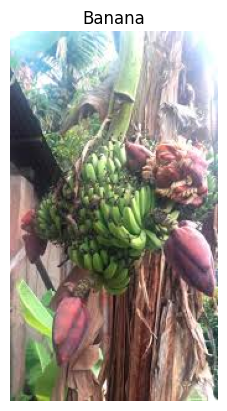

In [ ]:
img_name = os.listdir(f'/content/Fruits Classification/train/{classes[4]}')[0]
img_name

img_path = f'/content/Fruits Classification/train/{classes[4]}/{img_name}'
img = Image.open(img_path)

plt.imshow(img)
plt.title(classes[4])
plt.axis('off')
plt.show()

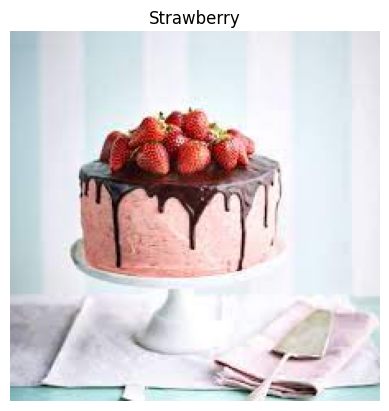

In [ ]:
img_name = os.listdir(f'/content/Fruits Classification/train/{classes[3]}')[0]
img_name

img_path = f'/content/Fruits Classification/train/{classes[3]}/{img_name}'
img = Image.open(img_path)

plt.imshow(img)
plt.title(classes[3])
plt.axis('off')
plt.show()

In [ ]:
from torchvision import datasets, transforms

transform = transforms.Compose([
    transforms.Resize((100, 100)), # H W
    transforms.ToTensor(), # tensor dataset
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # mean std
])

train_data = datasets.ImageFolder('/content/Fruits Classification/train', transform=transform)
valid_data = datasets.ImageFolder('/content/Fruits Classification/valid', transform=transform)
test_data  = datasets.ImageFolder('/content/Fruits Classification/test', transform=transform)

In [ ]:
print(len(train_data), len(valid_data), len(test_data))
print(train_data.classes)

9700 200 100
['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
DefaultConv2d = partial(nn.Conv2d, kernel_size=3, padding="same")

model = nn.Sequential(
    DefaultConv2d(3, 32, kernel_size=7),
    nn.ReLU(),
    nn.MaxPool2d(2),

    DefaultConv2d(32, 64),
    nn.ReLU(),
    nn.MaxPool2d(2),

    DefaultConv2d(64, 128),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.AdaptiveAvgPool2d(1),
    nn.Flatten(),
    nn.Linear(128, 5)
)

In [ ]:
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



In [ ]:
for epoch in range(10):
    model.train()
    train_loss = 0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)


        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss += loss.item()

    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in valid_loader:
            x, y = x.to(device), y.to(device)
            output = model(x)
            loss = criterion(output, y)
            val_loss += loss.item()

            pred = output.argmax(1)
            correct += (pred == y).sum().item()
            total += y.size(0)


    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {train_loss/len(train_loader):.4f}, "
        f"Val Loss: {val_loss/len(valid_loader):.4f}, "
        f"Val Acc: {correct/total:.4f} "

    )

Epoch 1, Train Loss: 1.2693, Val Loss: 1.2337, Val Acc: 0.4900 
Epoch 2, Train Loss: 1.1590, Val Loss: 1.1330, Val Acc: 0.5300 
Epoch 3, Train Loss: 1.1117, Val Loss: 1.1467, Val Acc: 0.5200 
Epoch 4, Train Loss: 1.0619, Val Loss: 0.9846, Val Acc: 0.5900 
Epoch 5, Train Loss: 1.0200, Val Loss: 0.9372, Val Acc: 0.6100 
Epoch 6, Train Loss: 0.9713, Val Loss: 0.9336, Val Acc: 0.5800 
Epoch 7, Train Loss: 0.9377, Val Loss: 0.8759, Val Acc: 0.6350 
Epoch 8, Train Loss: 0.9106, Val Loss: 0.8712, Val Acc: 0.6200 
Epoch 9, Train Loss: 0.8842, Val Loss: 0.8269, Val Acc: 0.6800 
Epoch 10, Train Loss: 0.8508, Val Loss: 0.8682, Val Acc: 0.6350 


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        out = model(x)
        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

print("Test Acc:", correct / total)

Test Acc: 0.69


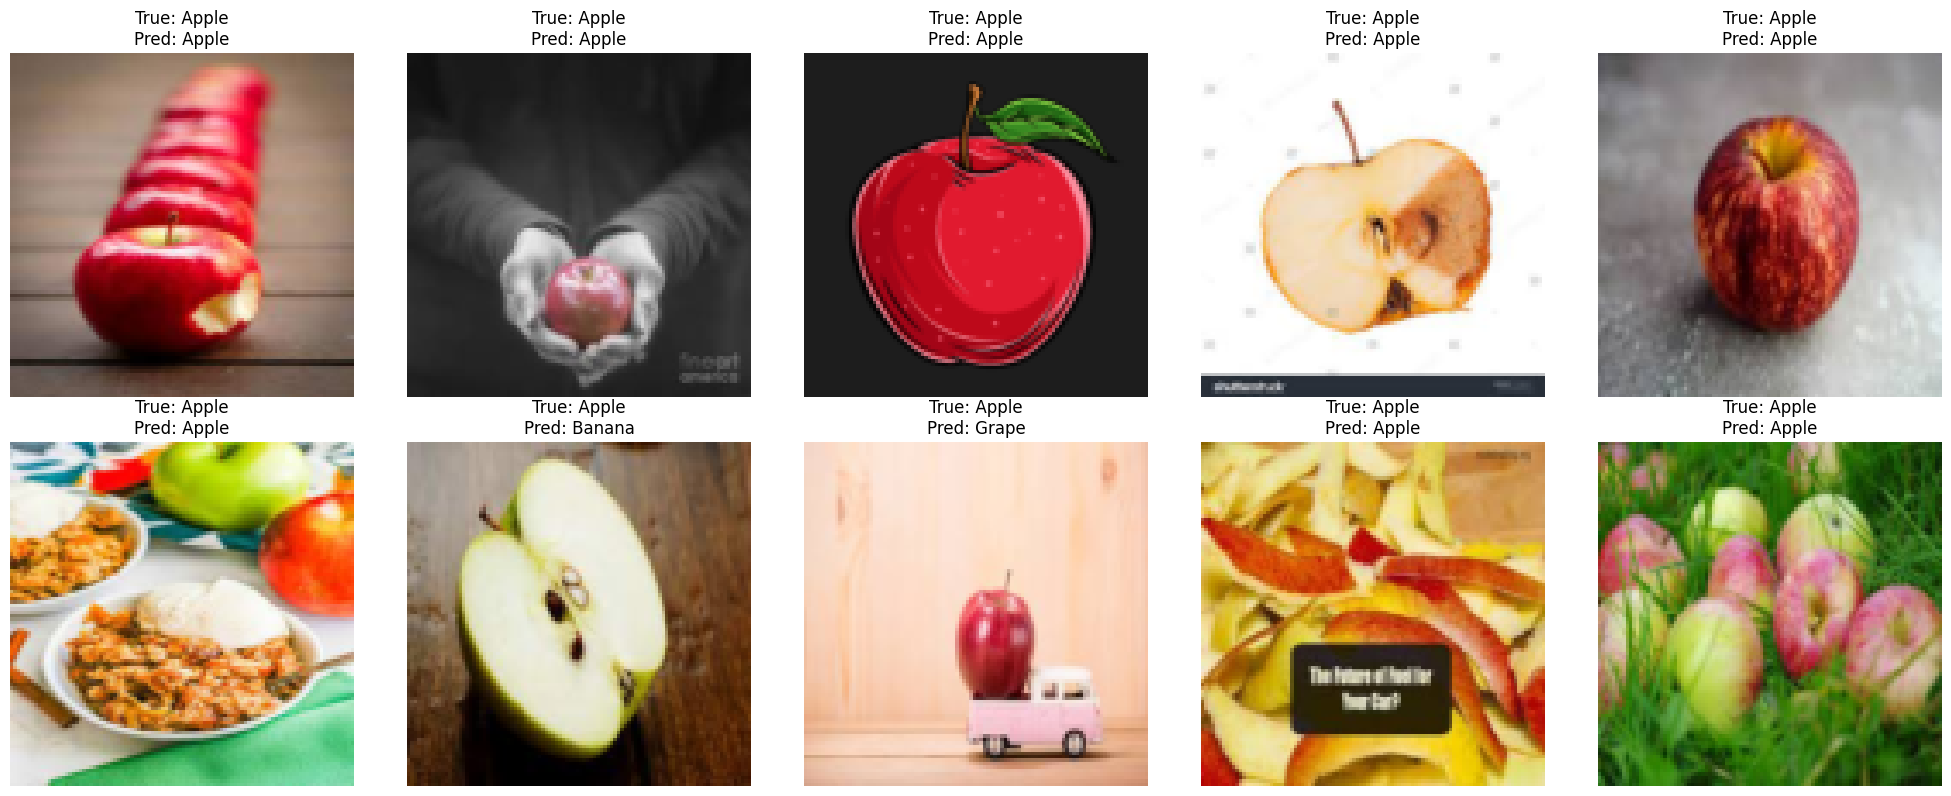

In [ ]:
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(1)

plt.figure(figsize=(20, 8))

for i in range(10):
    img = images[i].cpu().permute(1, 2, 0)
    img = img * 0.5 + 0.5

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"True: {test_data.classes[labels[i]]}\nPred: {test_data.classes[preds[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()